# EDP 1° ordem homogênea
### Bernardo Truccolo Schettini - 154235

Neste documento Python, fornece-se um algoritmo que realiza equações diferenciais parciais (EDP) homogêneas de 1° orderm:

$A \frac{\partial u}{\partial x} = B \frac{\partial u}{\partial t} $

Onde $u$ é uma função dependete das variáveis distânica $(x)$ e tempo $(t)$. Terá como condição inicial de $u(x,0) = f(x)$. $f(x)$ terá o formato de $C_1, C_2 e^{a_1x}$, ou $ C_3 e^{a_2x} + C_4 e^{a_3x}.$

## Importações e definições

Na realização do algorítimo, foram utilizados as bibliotecas numpy, sympy e time para desenvolver o algorítimo.

Antes de começar, $e$  foi definido através do sympy como o número de Euler, $x$ e $t$ são definidos como variáveis distância e tempo, respectivamente, via a biblioteca sympy.

In [1]:
import numpy as np
import sympy as sp
import time
import matplotlib.pyplot as plt

e = sp.E
x, t = sp.symbols('x, t')


def sleep(n):
  time.sleep(n)

In [2]:
3/.7

4.285714285714286

## Funções

Para resolver os casos possíveis da EDP homogênea, foi desenvolvido a função "edp_1ordemh", na qual o usuário descreve os elementos da EDP para que o algoritmo resolva a EDP. 




### 1) $u(x,0) = C_1$
Para casos quando a condição inicial for $u(x,0)=C_1$, onde "C1" é uma constante real e positiva, foi desenvolvido a função "edp1" na qual requer que o usuário escreva os valores de "A" e "B" que acompanham a EDP na qual quer resolver. O algoritmo no final demonstra também o gráfico do reusltado da EDP.

In [19]:
def edp1(A,B):
    
    C = float(input('Valor de C1:'))

    l = 0

    sol = C*e**((l/A*x + l/(-B)*t))

    xi = np.linspace(-1,1,10)
    ti = np.linspace(0,1,10)

    X,T = np.meshgrid(xi,ti)

    U = np.full_like(X, C)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, T, U, cmap='viridis')

    # Labels
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_zlabel('u(x, t)')

    return sol


### 2) $u(x,0) = C_2 e^{a_1x}$

Quando a condição inicial for $u(0,x) = C_2e^{ax}$, onde "C2" e "a" são constantes reais e positivas, utiliza-se a função "edp2", na qual similarmente a "edp1" requer que o usuário informe os valores de "A" e "B", mas também após começar o algoritmo será nescessário informar os valores de "C2" e "a". O algoritmo no final demonstra também o gráfico do reusltado da EDP.

In [17]:
def edp2(A,B):
    
    C = float(input('Valor de C2:'))
    a = float(input('Valor de a:'))

    l = A*-a

    sol = C*e**((l/A*x + l/B*t))
    
    xi = np.linspace(-1, 1, 10)
    ti = np.linspace(0, 1, 10)
    X, T = np.meshgrid(xi, ti)
    U = C*np.exp(l/A*X + l/B*T)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, T, U, cmap='viridis')

    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_zlabel('u(x, t)')
      
    
    return sol



### 3) $u(x,0) = C_3 e^{a_2x} + C_4 e^{a_3x}$

A "edp3" é para quando a condição inicial for $u(0,x) = C3e^{a_2x} + C4e^{a_3x}$, onde "C3", "C4", "a2" e "a3" são constantes reais e positivas. Similarmente à "edp2", inicia-se informando "A" e "B", prosseguindo com "C3", "C4", "a2" e "a3". O algoritmo no final demonstra também o gráfico do reusltado da EDP.

In [21]:
def edp3(A,B):

    C3 = float(input('Valor de C3:'))
    C4 = float(input('Valor de C4:'))

    a2 = float(input('Valor de a2:'))
    a3 = float(input('Valor de a3:'))

    l1 = (-a2*A)
    l2 = (-a3*A)

    sol = C3*e**((l1/A*x + l1/B*t)) + C4*e**(l2/A*x + l2/B*t)

    # Define a função u(x, t) = e^(-3x - 12t)
    xi = np.linspace(-1,1,10)
    ti = np.linspace(0,1,10)
    X, T = np.meshgrid(xi, ti)
    U = C3*np.exp(l1/A*X + l1/B*T) + C4*np.exp(l2/A*X + l2/B*T)

    # Cria o gráfico 3D
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, T, U, cmap='viridis')

    # Rótulos dos eixos
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_zlabel('u(x, t)')
    return sol



### Algorítimo geral para EDP's homogêneas

Tendo determinado "edp1", "edp2" e "edp3" para os possíveis casos de condição inicial para $u(x,0)$, foi desenvolvido a função "edp_1ordemh". Na qual para iniciar, basta escrever quaisquer número, logo após o programa pede para informar quais os valores de "A" e "B" da EDP. A seguir, o usuário será perguntado qual o tipo da condição inicial para $u(x,0)$, dependendo de qual o usuário escolhe, irá começar umas das funções determinadas anteriormente. Caso for escolhido uma resposta não válida para começar, o programa irá parar e solicitar para recomeçar.

In [6]:
def sleep(n):
    time.sleep(n)


def edp_1ordemh(a):

    
    #print('Este algorítimo serve para resolver EDPs de 1° ordem como mostradas anteriormente.')
    #sleep(2)
    
    A = float(input('Determine a constante A que acompanha ux'))
    B = float(input('Determine a constante B que acompanha ut'))

    decisão1 = int(input('Determine a condição inicial u(0,x), digite "1" para C1, "2" para C_2 e^{1x}, e "3" C_3 e^{a_2x} + C_4 e^{a_3x}:'))

    #sleep(1)

    if decisão1==1:
        print('u(X,0) = C1')
        sleep(2)

        a = edp1(A,B)
        print('Solução e gráfico da EDP é:')
        return a
        
    
    elif decisão1==2:
        print('u(X,0) = C2 e^(a1x)')
        sleep(2)

        a = edp2(A,B)
        print('Solução e gráfico da EDP é:')
        return a

    elif decisão1==3:
        print('u(X,0) = C_3 e^{a_2x} + C_4 e^{a_3x}')
        sleep(2)

        a = edp3(A,B)
        print('Solução e gráfico da EDP é:')
        return a

    else:
        print('Escolheu u(X,0) não válido, tente novamente.')
        
         
            

          
    

## Soluções de problemas

Segue exemplos para serem resolvidos via o algorítimo "edp_1ordem", para a seguinte EDP:

$ 4 \frac{\partial u}{\partial x} =  \frac{\partial u}{\partial t}  $



### 1) 

$u(0,x) = 8$


Determine a constante A que acompanha ux 4
Determine a constante B que acompanha ut 1
Determine a condição inicial u(0,x), digite "1" para C1, "2" para C_2 e^{1x}, e "3" C_3 e^{a_2x} + C_4 e^{a_3x}: 1


u(X,0) = C1


Valor de C1: 8


Solução e gráfico da EDP é:


8.00000000000000

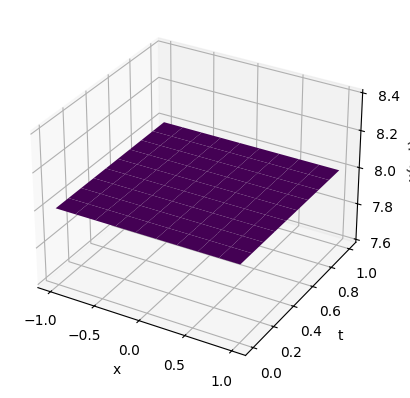

In [22]:
edp_1ordemh(1)

### 2)

$u(0,x) = 8e^{-3x}$


Determine a constante A que acompanha ux 4
Determine a constante B que acompanha ut 1
Determine a condição inicial u(0,x), digite "1" para C1, "2" para C_2 e^{1x}, e "3" C_3 e^{a_2x} + C_4 e^{a_3x}: 2


u(X,0) = C2 e^(a1x)


Valor de C2: 8
Valor de a: 3


Solução e gráfico da EDP é:


8.0*exp(-12.0*t - 3.0*x)

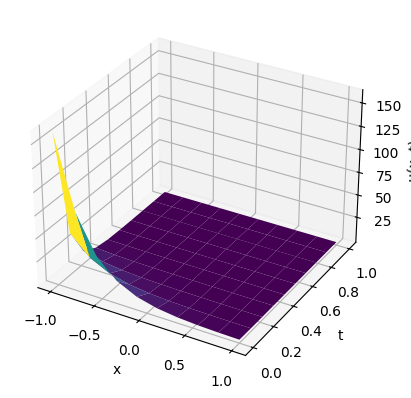

In [25]:
edp_1ordemh(1)

### 3)

$u(0,x) = 8e^{-3x} + 4e^{-5x}$


Determine a constante A que acompanha ux 4
Determine a constante B que acompanha ut 1
Determine a condição inicial u(0,x), digite "1" para C1, "2" para C_2 e^{1x}, e "3" C_3 e^{a_2x} + C_4 e^{a_3x}: 3


u(X,0) = C_3 e^{a_2x} + C_4 e^{a_3x}


Valor de C3: 8
Valor de C4: 4
Valor de a2: 3
Valor de a3: 5


Solução e gráfico da EDP é:


4.0*exp(-20.0*t - 5.0*x) + 8.0*exp(-12.0*t - 3.0*x)

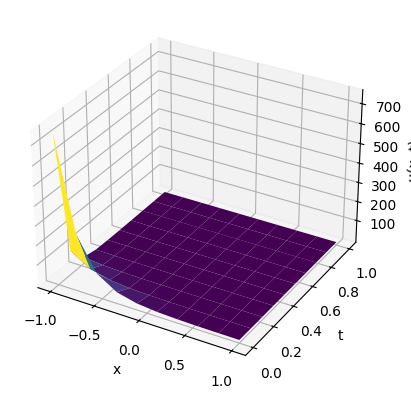

In [26]:
edp_1ordemh(1)